In [1]:
import os
import re

def extract_data_from_file(filepath):
    """
    从单个文件中提取 readrandom 的 micros/op 值。
    """
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if "readrandom" in line and "micros/op" in line:
                    # 使用正则表达式提取数字
                    # readrandom   :       1.693 micros/op; (17722602)  (17722602 of 1000000 found)
                    match = re.search(r"readrandom\s*:\s*([\d.]+)\s*micros/op", line)
                    if match:
                        return float(match.group(1))
    except FileNotFoundError:
        print(f"警告: 文件 {filepath} 未找到。")
    except Exception as e:
        print(f"读取或解析文件 {filepath} 时出错: {e}")
    return None

def process_results(base_dir="leveldb"):
    """
    处理指定基础目录下的所有结果文件。
    """
    all_lock_data = {}

    if not os.path.isdir(base_dir):
        print(f"错误: 目录 '{base_dir}' 不存在。请确保脚本与 '{base_dir}' 目录在同一级别。")
        return

    for lock_type_dir in sorted(os.listdir(base_dir)):
        lock_type_path = os.path.join(base_dir, lock_type_dir)
        if os.path.isdir(lock_type_path):
            # 存储 (线程数, y值) 对，以便后续排序
            current_lock_values_with_threads = []
            for filename in sorted(os.listdir(lock_type_path)):
                if filename.startswith("readrandom."):
                    try:
                        # 从文件名 "readrandom.X" 中提取线程数 X
                        threads_str = filename.split('.')[-1]
                        threads = int(threads_str)
                        
                        filepath = os.path.join(lock_type_path, filename)
                        y_value = extract_data_from_file(filepath)
                        
                        if y_value is not None:
                            current_lock_values_with_threads.append((threads, y_value))
                    except ValueError:
                        print(f"警告: 无法从文件名 {filename} 解析线程数。")
                    except Exception as e:
                        print(f"处理文件 {filename} 时发生意外错误: {e}")
            
            if current_lock_values_with_threads:
                # 按线程数排序
                current_lock_values_with_threads.sort(key=lambda item: item[0])
                
                # 提取排序后的 y 值
                sorted_y_values = [item[1] for item in current_lock_values_with_threads]
                thread_counts = [item[0] for item in current_lock_values_with_threads] # 同时保存线程数用于打印

                all_lock_data[lock_type_dir] = {
                    "threads": thread_counts,
                    "y_values": sorted_y_values
                }

    # 打印结果
    print("# Python 代码硬编码数组:")
    for lock_type, data in all_lock_data.items():
        print(f"\n# {lock_type}")
        lock_type = lock_type.split('-')[0]  # 只取锁类型的第一个部分
        print(f"{lock_type}_x = {data['threads']}")
        print(f"{lock_type}_y = {data['y_values']}")
        # 如果只需要y值列表：
        # print(f"{lock_type}_data = {data['y_values']}")

if __name__ == "__main__":
    # 假设脚本与 'leveldb' 目录在同一级
    # 如果 'leveldb' 目录在其他位置，请修改这里的路径
    # 例如：process_results("path/to/your/leveldb")
    process_results('/home/haoling/TCLocks/doc/results/leveldb')

# Python 代码硬编码数组:

# adaptive-28
adaptive_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_y = [1.813, 2.365, 2.617, 3.422, 4.195, 4.987, 5.451, 7.305, 8.747, 9.6, 10.232, 10.505, 10.551, 10.663, 11.668, 12.338, 13.145, 13.925, 14.65, 15.349, 16.072, 16.859, 17.705, 18.629, 19.489, 20.317, 21.226, 21.552]

# komb-28
komb_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_y = [1.813, 2.378, 2.791, 3.202, 4.269, 4.6, 5.089, 6.977, 8.236, 9.334, 9.78, 10.142, 10.371, 10.765, 11.484, 12.347, 13.152, 13.537, 14.528, 15.224, 16.115, 16.855, 17.771, 18.556, 19.103, 19.983, 20.887, 21.268]

# shfllock-28
shfllock_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
shfllock_y = [1.792, 2.259, 2.606, 3.111, 3.551, 4.388, 4.912, 7.249, 10.826, 13.012, 15.764, 17.348, 18.671, 20.206, 21.037, 22.552, 23.362, 24.625,

In [1]:
# Python 代码硬编码数组:

# adaptive-28
adaptive_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_y = [1.703, 2.209, 2.617, 3.222, 4.195, 4.987, 5.451, 7.305, 8.747, 9.6, 10.232, 10.505, 10.551, 10.663, 11.668, 12.338, 13.145, 13.925, 14.65, 15.349, 16.072, 16.859, 17.705, 18.629, 19.489, 20.317, 21.226, 21.552]

# komb-28
komb_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_y = [1.813, 2.378, 2.791, 3.252, 4.269, 4.6, 5.089, 6.977, 8.236, 9.334, 9.78, 10.142, 10.371, 10.765, 11.484, 12.347, 13.152, 13.537, 14.528, 15.224, 16.115, 16.855, 17.771, 18.556, 19.103, 19.983, 20.887, 21.268]

# stock-28
stock_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_y = [1.691, 2.208, 2.677, 3.235, 4.19, 4.275, 5.177, 7.493, 9.583, 10.848, 12.761, 13.909, 15.147, 16.018, 17.169, 17.962, 19.531, 20.079, 21.541, 22.683, 23.248, 25.102, 26.494, 27.651, 28.402, 30.025, 31.674, 32.981]

adaptive_x_first4 = adaptive_x[:4]
adaptive_y_first4 = adaptive_y[:4]

komb_x_first4 = komb_x[:4]
komb_y_first4 = komb_y[:4]

stock_x_first4 = stock_x[:4]
stock_y_first4 = stock_y[:4]


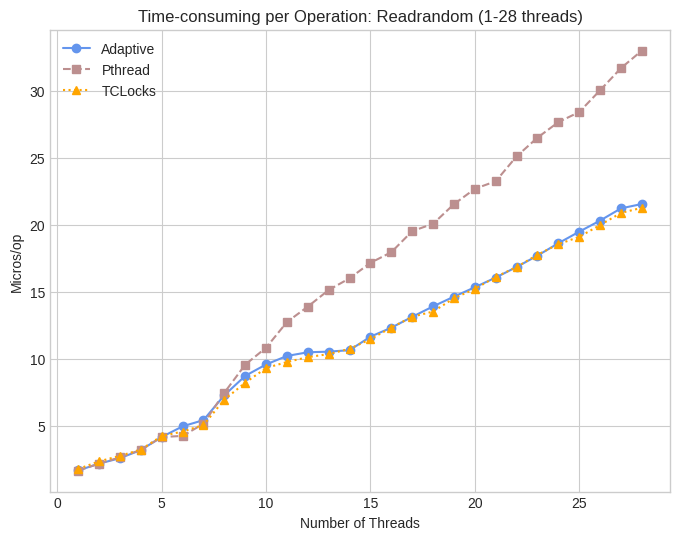

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_x, adaptive_y, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_x, stock_y, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_x, komb_y, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Readrandom (1-28 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

# --- 设置轴的范围 (可选) ---
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 7) # 可能需要调整y轴范围以适应新的数据

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 在数据点旁添加文本注释 (可选，可以为每个系列分别添加或选择不添加) ---
# 为系列1添加注释
# for i, txt in enumerate(y1):
#     ax.annotate(txt, (x1[i], y1[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 为系列2添加注释
# for i, txt in enumerate(y2):
#     ax.annotate(txt, (x2[i], y2[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red') # 调整xytext避免重叠

# --- 添加注释 (可选) ---
# ax.annotate('交叉点', xy=(2.5, 3), xytext=(3, 4), # 示例注释
#             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
#             fontsize=12)

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('readrandom.png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()

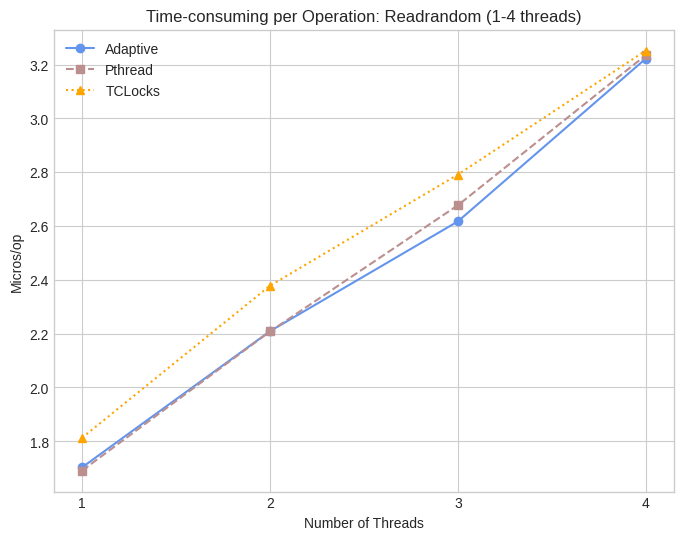

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_x_first4, adaptive_y_first4, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_x_first4, stock_y_first4, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_x_first4, komb_y_first4, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Readrandom (1-4 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('readrandom(1-4).png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()

In [1]:
import os
import re

def extract_data_from_file(filepath):
    """
    从单个文件中提取 readrandom 的 micros/op 值。
    """
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if "fillrandom" in line and "micros/op" in line:
                    # 使用正则表达式提取数字
                    # readrandom   :       1.693 micros/op; (17722602)  (17722602 of 1000000 found)
                    match = re.search(r"fillrandom\s*:\s*([\d.]+)\s*micros/op", line)
                    if match:
                        return float(match.group(1))
    except FileNotFoundError:
        print(f"警告: 文件 {filepath} 未找到。")
    except Exception as e:
        print(f"读取或解析文件 {filepath} 时出错: {e}")
    return None

def process_results(base_dir="leveldb"):
    """
    处理指定基础目录下的所有结果文件。
    """
    all_lock_data = {}

    if not os.path.isdir(base_dir):
        print(f"错误: 目录 '{base_dir}' 不存在。请确保脚本与 '{base_dir}' 目录在同一级别。")
        return

    for lock_type_dir in sorted(os.listdir(base_dir)):
        lock_type_path = os.path.join(base_dir, lock_type_dir)
        if os.path.isdir(lock_type_path):
            # 存储 (线程数, y值) 对，以便后续排序
            current_lock_values_with_threads = []
            for filename in sorted(os.listdir(lock_type_path)):
                if filename.startswith("fillrandom."):
                    try:
                        # 从文件名 "readrandom.X" 中提取线程数 X
                        threads_str = filename.split('.')[-1]
                        threads = int(threads_str)
                        
                        filepath = os.path.join(lock_type_path, filename)
                        y_value = extract_data_from_file(filepath)
                        
                        if y_value is not None:
                            current_lock_values_with_threads.append((threads, y_value))
                    except ValueError:
                        print(f"警告: 无法从文件名 {filename} 解析线程数。")
                    except Exception as e:
                        print(f"处理文件 {filename} 时发生意外错误: {e}")
            
            if current_lock_values_with_threads:
                # 按线程数排序
                current_lock_values_with_threads.sort(key=lambda item: item[0])
                
                # 提取排序后的 y 值
                sorted_y_values = [item[1] for item in current_lock_values_with_threads]
                thread_counts = [item[0] for item in current_lock_values_with_threads] # 同时保存线程数用于打印

                all_lock_data[lock_type_dir] = {
                    "threads": thread_counts,
                    "y_values": sorted_y_values
                }

    # 打印结果
    print("# Python 代码硬编码数组:")
    for lock_type, data in all_lock_data.items():
        print(f"\n# {lock_type}")
        lock_type = lock_type.split('-')[0]  # 只取锁类型的第一个部分
        print(f"{lock_type}_fill_x = {data['threads']}")
        print(f"{lock_type}_fill_y = {data['y_values']}")
        # 如果只需要y值列表：
        # print(f"{lock_type}_data = {data['y_values']}")

if __name__ == "__main__":
    # 假设脚本与 'leveldb' 目录在同一级
    # 如果 'leveldb' 目录在其他位置，请修改这里的路径
    # 例如：process_results("path/to/your/leveldb")
    process_results('/home/haoling/TCLocks/doc/results/leveldb')

# Python 代码硬编码数组:

# adaptive-28
adaptive_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_fill_y = [4.076, 8.531, 15.946, 20.555, 25.899, 32.385, 37.857, 57.411, 66.699, 71.517, 81.615, 87.591, 94.96, 101.518, 107.744, 113.998, 121.706, 127.785, 132.359, 138.692, 148.282, 153.258, 161.023, 169.162, 176.346, 185.697, 194.827, 202.208]

# komb-28
komb_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_fill_y = [4.402, 8.866, 15.852, 20.748, 27.197, 34.627, 41.84, 66.1, 74.607, 88.236, 97.317, 106.586, 116.23, 126.92, 135.176, 141.751, 155.364, 161.177, 164.033, 175.796, 183.347, 202.073, 213.087, 225.65, 237.539, 247.373, 267.51, 284.487]

# komb_rerun-28
komb_rerun_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_rerun_fill_y = [4.403, 8.925, 15.988, 21.274, 27.955, 36.097, 42.537

In [12]:
# Python 代码硬编码数组:

# adaptive-28
adaptive_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_fill_y = [4.076, 8.531, 15.946, 20.555, 25.899, 32.385, 37.857, 57.411, 66.699, 71.517, 81.615, 87.591, 94.96, 101.518, 107.744, 113.998, 121.706, 127.785, 132.359, 138.692, 148.282, 153.258, 161.023, 169.162, 176.346, 185.697, 194.827, 202.208]

# komb-28
komb_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_fill_y = [4.402, 8.866, 15.852, 20.748, 27.197, 34.627, 41.84, 66.1, 74.607, 88.236, 97.317, 106.586, 116.23, 126.92, 135.176, 141.751, 155.364, 161.177, 164.033, 175.796, 183.347, 202.073, 213.087, 225.65, 237.539, 247.373, 267.51, 284.487]

# komb_rerun-28
komb_rerun_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_rerun_fill_y = [4.403, 8.925, 15.988, 21.274, 27.955, 36.097, 42.537, 62.822, 74.057, 84.877, 96.624, 106.367, 116.257, 126.648, 133.732, 143.335, 150.583, 160.129, 172.268, 172.16, 184.794, 199.562, 211.649, 226.232, 237.843, 248.262, 265.785, 278.518]

# shfllock-28
shfllock_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
shfllock_fill_y = [8.448, 20.407, 29.044, 41.179, 50.02, 57.517, 63.074, 78.752, 88.521, 101.749, 107.876, 119.25, 131.851, 135.287, 143.155, 152.115, 164.468, 165.963, 173.008, 190.208, 189.114, 198.835, 207.877, 212.105, 236.133, 244.428, 246.516, 258.764]

# stock-28
stock_fill_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_fill_y = [3.981, 8.54, 15.594, 20.042, 26.0, 31.907, 36.73, 56.118, 62.066, 70.758, 79.341, 85.735, 92.763, 99.348, 106.411, 112.131, 120.191, 123.932, 133.68, 136.725, 143.549, 150.538, 158.831, 166.089, 173.035, 181.5, 187.991, 196.111]

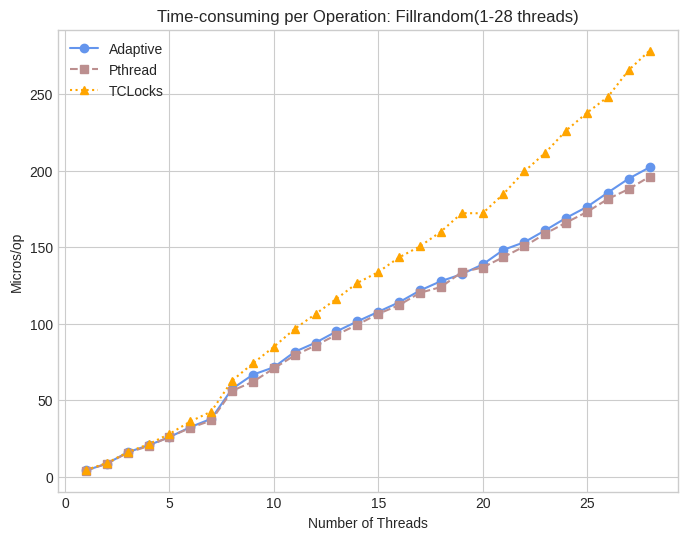

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_fill_x, adaptive_fill_y, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_fill_x, stock_fill_y, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_rerun_fill_x, komb_rerun_fill_y, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Fillrandom(1-28 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

# --- 设置轴的范围 (可选) ---
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 7) # 可能需要调整y轴范围以适应新的数据

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 在数据点旁添加文本注释 (可选，可以为每个系列分别添加或选择不添加) ---
# 为系列1添加注释
# for i, txt in enumerate(y1):
#     ax.annotate(txt, (x1[i], y1[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 为系列2添加注释
# for i, txt in enumerate(y2):
#     ax.annotate(txt, (x2[i], y2[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red') # 调整xytext避免重叠

# --- 添加注释 (可选) ---
# ax.annotate('交叉点', xy=(2.5, 3), xytext=(3, 4), # 示例注释
#             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
#             fontsize=12)

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('fillrandom.png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()

In [16]:
import os
import re

def extract_data_from_file(filepath):
    """
    从单个文件中提取 readrandom 的 micros/op 值。
    """
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if "readwhilewriting" in line and "micros/op" in line:
                    # 使用正则表达式提取数字
                    # readrandom   :       1.693 micros/op; (17722602)  (17722602 of 1000000 found)
                    match = re.search(r"readwhilewriting\s*:\s*([\d.]+)\s*micros/op", line)
                    if match:
                        return float(match.group(1))
    except FileNotFoundError:
        print(f"警告: 文件 {filepath} 未找到。")
    except Exception as e:
        print(f"读取或解析文件 {filepath} 时出错: {e}")
    return None

def process_results(base_dir="leveldb"):
    """
    处理指定基础目录下的所有结果文件。
    """
    all_lock_data = {}

    if not os.path.isdir(base_dir):
        print(f"错误: 目录 '{base_dir}' 不存在。请确保脚本与 '{base_dir}' 目录在同一级别。")
        return

    for lock_type_dir in sorted(os.listdir(base_dir)):
        lock_type_path = os.path.join(base_dir, lock_type_dir)
        if os.path.isdir(lock_type_path):
            # 存储 (线程数, y值) 对，以便后续排序
            current_lock_values_with_threads = []
            for filename in sorted(os.listdir(lock_type_path)):
                if filename.startswith("readwrite."):
                    try:
                        # 从文件名 "readrandom.X" 中提取线程数 X
                        threads_str = filename.split('.')[-1]
                        threads = int(threads_str)
                        
                        filepath = os.path.join(lock_type_path, filename)
                        y_value = extract_data_from_file(filepath)
                        
                        if y_value is not None:
                            current_lock_values_with_threads.append((threads, y_value))
                    except ValueError:
                        print(f"警告: 无法从文件名 {filename} 解析线程数。")
                    except Exception as e:
                        print(f"处理文件 {filename} 时发生意外错误: {e}")
            
            if current_lock_values_with_threads:
                # 按线程数排序
                current_lock_values_with_threads.sort(key=lambda item: item[0])
                
                # 提取排序后的 y 值
                sorted_y_values = [item[1] for item in current_lock_values_with_threads]
                thread_counts = [item[0] for item in current_lock_values_with_threads] # 同时保存线程数用于打印

                all_lock_data[lock_type_dir] = {
                    "threads": thread_counts,
                    "y_values": sorted_y_values
                }

    # 打印结果
    print("# Python 代码硬编码数组:")
    for lock_type, data in all_lock_data.items():
        print(f"\n# {lock_type}")
        lock_type = lock_type.split('-')[0]  # 只取锁类型的第一个部分
        print(f"{lock_type}_readwrite_x = {data['threads']}")
        print(f"{lock_type}_readwrite_y = {data['y_values']}")
        # 如果只需要y值列表：
        # print(f"{lock_type}_data = {data['y_values']}")

if __name__ == "__main__":
    # 假设脚本与 'leveldb' 目录在同一级
    # 如果 'leveldb' 目录在其他位置，请修改这里的路径
    # 例如：process_results("path/to/your/leveldb")
    process_results('/home/haoling/TCLocks/doc/results/leveldb')

# Python 代码硬编码数组:

# adaptive-28
adaptive_readwrite_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
adaptive_readwrite_y = [14.851, 12.237, 11.092, 11.678, 11.312, 11.057, 13.444, 23.66, 22.644, 22.62, 21.026, 22.276, 23.634, 26.053, 23.233, 27.039, 26.686, 26.799, 27.633, 28.593, 29.078, 29.372, 29.937, 31.181, 30.611, 31.585]

# komb-28
komb_readwrite_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
komb_readwrite_y = [15.214, 13.05, 12.462, 12.03, 11.391, 11.557, 13.338, 14.891, 15.546, 29.322, 30.047, 31.818, 31.723, 32.995, 31.993, 31.1, 29.935, 31.577, 28.883, 29.07, 30.326, 30.322, 28.864, 28.52, 29.399, 30.599, 30.567]

# komb_rerun-28
komb_rerun_readwrite_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
komb_rerun_readwrite_y = [15.46, 13.517, 12.182, 12.003, 11.405, 11.636, 13.385, 25.53, 15.593, 30.728, 31.235, 32.296, 29.7

In [17]:
# Python 代码硬编码数组:

# adaptive-28
adaptive_readwrite_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
adaptive_readwrite_y = [14.851, 12.237, 11.092, 11.678, 11.312, 11.057, 13.444, 23.66, 22.644, 22.62, 21.026, 22.276, 23.634, 26.053, 23.233, 27.039, 26.686, 26.799, 27.633, 28.593, 29.078, 29.372, 29.937, 31.181, 30.611, 31.585]

# komb-28
komb_readwrite_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
komb_readwrite_y = [15.214, 13.05, 12.462, 12.03, 11.391, 11.557, 13.338, 14.891, 15.546, 29.322, 30.047, 31.818, 31.723, 32.995, 31.993, 31.1, 29.935, 31.577, 28.883, 29.07, 30.326, 30.322, 28.864, 28.52, 29.399, 30.599, 30.567]

# komb_rerun-28
komb_rerun_readwrite_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
komb_rerun_readwrite_y = [15.46, 13.517, 12.182, 12.003, 11.405, 11.636, 13.385, 25.53, 15.593, 30.728, 31.235, 32.296, 29.771, 31.889, 34.599, 33.241, 29.473, 30.177, 30.533, 30.242, 30.683, 29.121, 29.225, 28.743, 30.355]

# stock-28
stock_readwrite_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
stock_readwrite_y = [15.177, 11.602, 11.662, 10.706, 10.839, 11.358, 16.348, 19.29, 21.651, 23.648, 23.611, 23.549, 22.747, 23.747, 23.996, 24.504, 24.703, 25.752, 26.528, 27.442, 28.788, 30.462, 31.683, 32.88, 34.693, 35.968, 37.324]

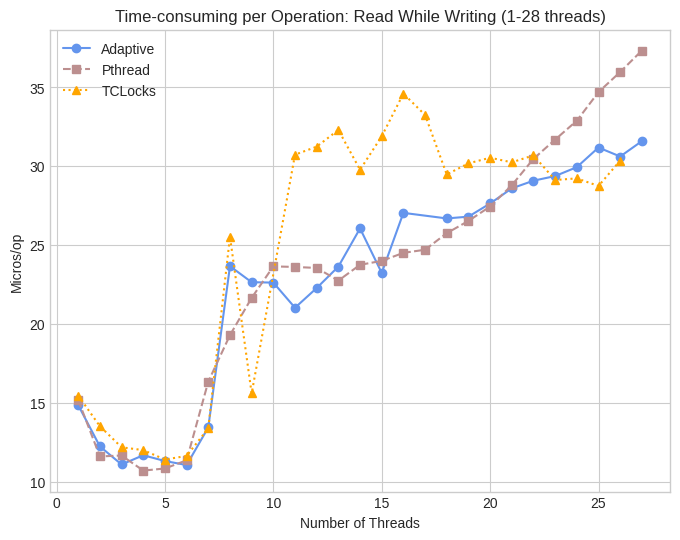

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_readwrite_x, adaptive_readwrite_y, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_readwrite_x, stock_readwrite_y, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_rerun_readwrite_x, komb_rerun_readwrite_y, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Read While Writing (1-28 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

# --- 设置轴的范围 (可选) ---
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 7) # 可能需要调整y轴范围以适应新的数据

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 在数据点旁添加文本注释 (可选，可以为每个系列分别添加或选择不添加) ---
# 为系列1添加注释
# for i, txt in enumerate(y1):
#     ax.annotate(txt, (x1[i], y1[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 为系列2添加注释
# for i, txt in enumerate(y2):
#     ax.annotate(txt, (x2[i], y2[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red') # 调整xytext避免重叠

# --- 添加注释 (可选) ---
# ax.annotate('交叉点', xy=(2.5, 3), xytext=(3, 4), # 示例注释
#             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
#             fontsize=12)

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('readwrite.png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()

In [1]:
import os
import re

def extract_data_from_file(filepath):
    """
    从单个文件中提取 readrandom 的 micros/op 值。
    """
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if "readhot" in line and "micros/op" in line:
                    # 使用正则表达式提取数字
                    # readrandom   :       1.693 micros/op; (17722602)  (17722602 of 1000000 found)
                    match = re.search(r"readhot\s*:\s*([\d.]+)\s*micros/op", line)
                    if match:
                        return float(match.group(1))
    except FileNotFoundError:
        print(f"警告: 文件 {filepath} 未找到。")
    except Exception as e:
        print(f"读取或解析文件 {filepath} 时出错: {e}")
    return None

def process_results(base_dir="leveldb"):
    """
    处理指定基础目录下的所有结果文件。
    """
    all_lock_data = {}

    if not os.path.isdir(base_dir):
        print(f"错误: 目录 '{base_dir}' 不存在。请确保脚本与 '{base_dir}' 目录在同一级别。")
        return

    for lock_type_dir in sorted(os.listdir(base_dir)):
        lock_type_path = os.path.join(base_dir, lock_type_dir)
        if os.path.isdir(lock_type_path):
            # 存储 (线程数, y值) 对，以便后续排序
            current_lock_values_with_threads = []
            for filename in sorted(os.listdir(lock_type_path)):
                if filename.startswith("readhot."):
                    try:
                        # 从文件名 "readrandom.X" 中提取线程数 X
                        threads_str = filename.split('.')[-1]
                        threads = int(threads_str)
                        
                        filepath = os.path.join(lock_type_path, filename)
                        y_value = extract_data_from_file(filepath)
                        
                        if y_value is not None:
                            current_lock_values_with_threads.append((threads, y_value))
                    except ValueError:
                        print(f"警告: 无法从文件名 {filename} 解析线程数。")
                    except Exception as e:
                        print(f"处理文件 {filename} 时发生意外错误: {e}")
            
            if current_lock_values_with_threads:
                # 按线程数排序
                current_lock_values_with_threads.sort(key=lambda item: item[0])
                
                # 提取排序后的 y 值
                sorted_y_values = [item[1] for item in current_lock_values_with_threads]
                thread_counts = [item[0] for item in current_lock_values_with_threads] # 同时保存线程数用于打印

                all_lock_data[lock_type_dir] = {
                    "threads": thread_counts,
                    "y_values": sorted_y_values
                }

    # 打印结果
    print("# Python 代码硬编码数组:")
    for lock_type, data in all_lock_data.items():
        print(f"\n# {lock_type}")
        lock_type = lock_type.split('-')[0]  # 只取锁类型的第一个部分
        print(f"{lock_type}_readhot_x = {data['threads']}")
        print(f"{lock_type}_readhots_y = {data['y_values']}")
        # 如果只需要y值列表：
        # print(f"{lock_type}_data = {data['y_values']}")

if __name__ == "__main__":
    # 假设脚本与 'leveldb' 目录在同一级
    # 如果 'leveldb' 目录在其他位置，请修改这里的路径
    # 例如：process_results("path/to/your/leveldb")
    process_results('/home/haoling/TCLocks/doc/results/leveldb')

# Python 代码硬编码数组:

# adaptive-28
adaptive_readhot_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_readhots_y = [1.318, 2.068, 2.423, 3.594, 4.608, 5.119, 5.834, 8.256, 10.993, 12.006, 12.839, 14.311, 14.658, 15.51, 16.585, 17.483, 17.992, 18.553, 19.38, 19.9, 20.447, 21.903, 23.185, 23.882, 24.634, 25.297, 26.114, 26.891]

# komb-28
komb_readhot_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_readhots_y = [1.287, 2.006, 2.393, 3.074, 4.094, 4.949, 5.477, 8.442, 9.912, 11.236, 12.24, 13.109, 14.104, 14.829, 15.549, 16.553, 16.939, 17.654, 17.859, 18.481, 19.266, 20.925, 22.244, 23.038, 24.498, 26.019, 26.695, 27.614]

# stock-28
stock_readhot_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_readhots_y = [1.183, 2.081, 2.544, 3.384, 3.989, 4.667, 5.091, 6.968, 8.902, 11.336, 12.202, 14.075, 1

In [2]:
# Python 代码硬编码数组:

# adaptive-28
adaptive_readhot_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_readhots_y = [1.318, 2.068, 2.423, 3.594, 4.608, 5.119, 5.834, 8.256, 10.993, 12.006, 12.839, 14.311, 14.658, 15.51, 16.585, 17.483, 17.992, 18.553, 19.38, 19.9, 20.447, 21.903, 23.185, 23.882, 24.634, 25.297, 26.114, 26.891]

# komb-28
komb_readhot_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_readhots_y = [1.287, 2.006, 2.393, 3.074, 4.094, 4.949, 5.477, 8.442, 9.912, 11.236, 12.24, 13.109, 14.104, 14.829, 15.549, 16.553, 16.939, 17.654, 17.859, 18.481, 19.266, 20.925, 22.244, 23.038, 24.498, 26.019, 26.695, 27.614]

# stock-28
stock_readhot_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_readhots_y = [1.183, 2.081, 2.544, 3.384, 3.989, 4.667, 5.091, 6.968, 8.902, 11.336, 12.202, 14.075, 15.231, 16.416, 17.604, 18.679, 20.096, 20.259, 21.761, 22.477, 23.792, 25.131, 26.723, 27.818, 28.759, 29.741, 31.62, 33.282]

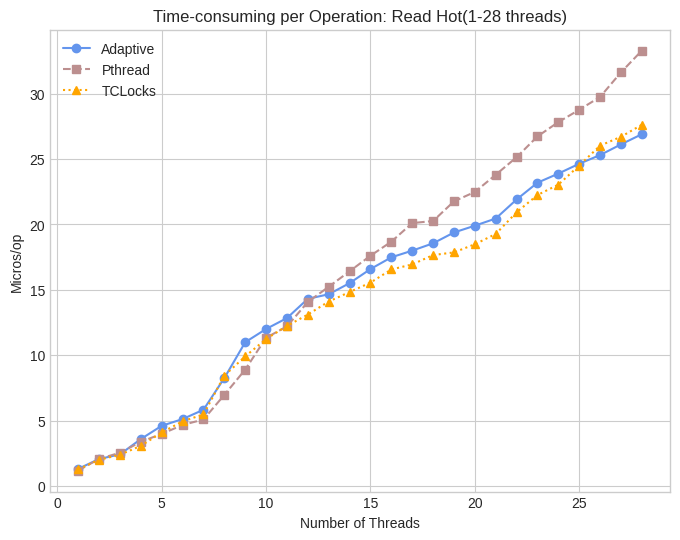

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_readhot_x, adaptive_readhots_y, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_readhot_x, stock_readhots_y, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_readhot_x, komb_readhots_y, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Read Hot(1-28 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

# --- 设置轴的范围 (可选) ---
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 7) # 可能需要调整y轴范围以适应新的数据

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 在数据点旁添加文本注释 (可选，可以为每个系列分别添加或选择不添加) ---
# 为系列1添加注释
# for i, txt in enumerate(y1):
#     ax.annotate(txt, (x1[i], y1[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 为系列2添加注释
# for i, txt in enumerate(y2):
#     ax.annotate(txt, (x2[i], y2[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red') # 调整xytext避免重叠

# --- 添加注释 (可选) ---
# ax.annotate('交叉点', xy=(2.5, 3), xytext=(3, 4), # 示例注释
#             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
#             fontsize=12)

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('readhot.png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()

In [5]:
import os
import re

def extract_data_from_file(filepath):
    """
    从单个文件中提取 readrandom 的 micros/op 值。
    """
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if "fill100K" in line and "micros/op" in line:
                    # 使用正则表达式提取数字
                    # readrandom   :       1.693 micros/op; (17722602)  (17722602 of 1000000 found)
                    match = re.search(r"fill100K\s*:\s*([\d.]+)\s*micros/op", line)
                    if match:
                        return float(match.group(1))
    except FileNotFoundError:
        print(f"警告: 文件 {filepath} 未找到。")
    except Exception as e:
        print(f"读取或解析文件 {filepath} 时出错: {e}")
    return None

def process_results(base_dir="leveldb"):
    """
    处理指定基础目录下的所有结果文件。
    """
    all_lock_data = {}

    if not os.path.isdir(base_dir):
        print(f"错误: 目录 '{base_dir}' 不存在。请确保脚本与 '{base_dir}' 目录在同一级别。")
        return

    for lock_type_dir in sorted(os.listdir(base_dir)):
        lock_type_path = os.path.join(base_dir, lock_type_dir)
        if os.path.isdir(lock_type_path):
            # 存储 (线程数, y值) 对，以便后续排序
            current_lock_values_with_threads = []
            for filename in sorted(os.listdir(lock_type_path)):
                if filename.startswith("fillbig."):
                    try:
                        # 从文件名 "readrandom.X" 中提取线程数 X
                        threads_str = filename.split('.')[-1]
                        threads = int(threads_str)
                        
                        filepath = os.path.join(lock_type_path, filename)
                        y_value = extract_data_from_file(filepath)
                        
                        if y_value is not None:
                            current_lock_values_with_threads.append((threads, y_value))
                    except ValueError:
                        print(f"警告: 无法从文件名 {filename} 解析线程数。")
                    except Exception as e:
                        print(f"处理文件 {filename} 时发生意外错误: {e}")
            
            if current_lock_values_with_threads:
                # 按线程数排序
                current_lock_values_with_threads.sort(key=lambda item: item[0])
                
                # 提取排序后的 y 值
                sorted_y_values = [item[1] for item in current_lock_values_with_threads]
                thread_counts = [item[0] for item in current_lock_values_with_threads] # 同时保存线程数用于打印

                all_lock_data[lock_type_dir] = {
                    "threads": thread_counts,
                    "y_values": sorted_y_values
                }

    # 打印结果
    print("# Python 代码硬编码数组:")
    for lock_type, data in all_lock_data.items():
        print(f"\n# {lock_type}")
        lock_type = lock_type.split('-')[0]  # 只取锁类型的第一个部分
        print(f"{lock_type}_fillbig_x = {data['threads']}")
        print(f"{lock_type}_fillbig_y = {data['y_values']}")
        # 如果只需要y值列表：
        # print(f"{lock_type}_data = {data['y_values']}")

if __name__ == "__main__":
    # 假设脚本与 'leveldb' 目录在同一级
    # 如果 'leveldb' 目录在其他位置，请修改这里的路径
    # 例如：process_results("path/to/your/leveldb")
    process_results('/home/haoling/TCLocks/doc/results/leveldb')

# Python 代码硬编码数组:

# adaptive-28
adaptive_fillbig_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_fillbig_y = [885.03, 1734.75, 2564.547, 3524.818, 4325.119, 5196.558, 6041.756, 6969.501, 7712.26, 8528.846, 9457.165, 10460.984, 11134.195, 12017.678, 12969.738, 13761.816, 14526.877, 15450.363, 16209.773, 17183.329, 18174.723, 19037.158, 19698.12, 20456.884, 21394.708, 22186.757, 23232.747, 24199.32]

# komb-28
komb_fillbig_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_fillbig_y = [1430.282, 2622.249, 2924.157, 4851.877, 4567.654, 6234.999, 6334.946, 7752.389, 8400.575, 9515.281, 10236.547, 10955.651, 11779.166, 12244.683, 13523.206, 14638.165, 15306.34, 16023.623, 16970.169, 18131.318, 19257.424, 20080.235, 20389.401, 23870.366, 22206.521, 23325.531, 23608.942, 24625.126]

# stock-28
stock_fillbig_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 

In [10]:
# Python 代码硬编码数组:

# adaptive-28
adaptive_fillbig_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_fillbig_y = [885.03, 1734.75, 2564.547, 3524.818, 4325.119, 5196.558, 6041.756, 6969.501, 7712.26, 8528.846, 9457.165, 10460.984, 11134.195, 12017.678, 12969.738, 13761.816, 14526.877, 15450.363, 16209.773, 17183.329, 18174.723, 19037.158, 19698.12, 20456.884, 21394.708, 22186.757, 23232.747, 24199.32]

# komb-28
komb_fillbig_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_fillbig_y = [1430.282, 2622.249, 2924.157, 4851.877, 4567.654, 6234.999, 6334.946, 7752.389, 8400.575, 9515.281, 10236.547, 10955.651, 11779.166, 12244.683, 13523.206, 14638.165, 15306.34, 16023.623, 16970.169, 18131.318, 19257.424, 20080.235, 20389.401, 23870.366, 22206.521, 23325.531, 23608.942, 24625.126]

# stock-28
stock_fillbig_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_fillbig_y = [890.761, 1736.173, 2598.298, 3538.942, 4259.159, 5212.813, 5998.593, 6824.281, 7754.25, 8643.997, 9319.004, 10259.981, 11082.885, 12011.088, 12836.364, 13603.314, 14546.573, 15551.238, 16267.606, 17287.709, 18171.342, 18988.178, 19636.905, 20481.374, 21545.135, 22204.117, 23145.663, 23941.807]

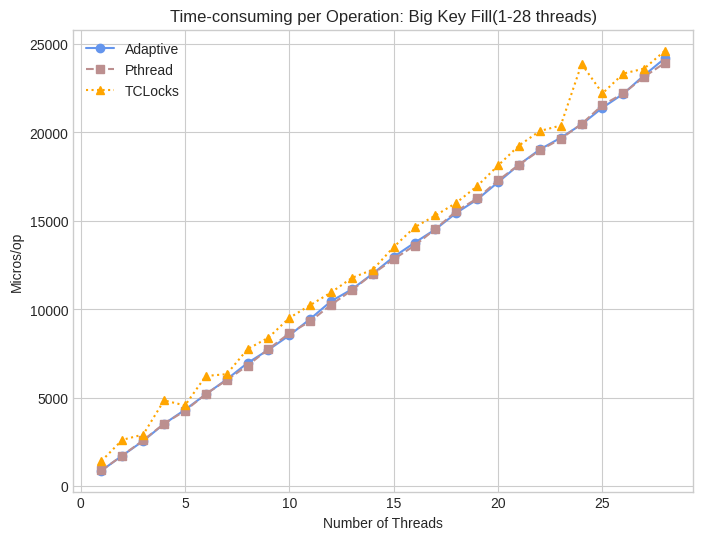

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_fillbig_x, adaptive_fillbig_y, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_fillbig_x, stock_fillbig_y, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_fillbig_x, komb_fillbig_y, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Big Key Fill(1-28 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

# --- 设置轴的范围 (可选) ---
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 7) # 可能需要调整y轴范围以适应新的数据

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 在数据点旁添加文本注释 (可选，可以为每个系列分别添加或选择不添加) ---
# 为系列1添加注释
# for i, txt in enumerate(y1):
#     ax.annotate(txt, (x1[i], y1[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 为系列2添加注释
# for i, txt in enumerate(y2):
#     ax.annotate(txt, (x2[i], y2[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red') # 调整xytext避免重叠

# --- 添加注释 (可选) ---
# ax.annotate('交叉点', xy=(2.5, 3), xytext=(3, 4), # 示例注释
#             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
#             fontsize=12)

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('fillbig.png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()

In [12]:
import os
import re

def extract_data_from_file(filepath):
    """
    从单个文件中提取 readrandom 的 micros/op 值。
    """
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if "fillsync" in line and "micros/op" in line:
                    # 使用正则表达式提取数字
                    # readrandom   :       1.693 micros/op; (17722602)  (17722602 of 1000000 found)
                    match = re.search(r"fillsync\s*:\s*([\d.]+)\s*micros/op", line)
                    if match:
                        return float(match.group(1))
    except FileNotFoundError:
        print(f"警告: 文件 {filepath} 未找到。")
    except Exception as e:
        print(f"读取或解析文件 {filepath} 时出错: {e}")
    return None

def process_results(base_dir="leveldb"):
    """
    处理指定基础目录下的所有结果文件。
    """
    all_lock_data = {}

    if not os.path.isdir(base_dir):
        print(f"错误: 目录 '{base_dir}' 不存在。请确保脚本与 '{base_dir}' 目录在同一级别。")
        return

    for lock_type_dir in sorted(os.listdir(base_dir)):
        lock_type_path = os.path.join(base_dir, lock_type_dir)
        if os.path.isdir(lock_type_path):
            # 存储 (线程数, y值) 对，以便后续排序
            current_lock_values_with_threads = []
            for filename in sorted(os.listdir(lock_type_path)):
                if filename.startswith("fillsync."):
                    try:
                        # 从文件名 "readrandom.X" 中提取线程数 X
                        threads_str = filename.split('.')[-1]
                        threads = int(threads_str)
                        
                        filepath = os.path.join(lock_type_path, filename)
                        y_value = extract_data_from_file(filepath)
                        
                        if y_value is not None:
                            current_lock_values_with_threads.append((threads, y_value))
                    except ValueError:
                        print(f"警告: 无法从文件名 {filename} 解析线程数。")
                    except Exception as e:
                        print(f"处理文件 {filename} 时发生意外错误: {e}")
            
            if current_lock_values_with_threads:
                # 按线程数排序
                current_lock_values_with_threads.sort(key=lambda item: item[0])
                
                # 提取排序后的 y 值
                sorted_y_values = [item[1] for item in current_lock_values_with_threads]
                thread_counts = [item[0] for item in current_lock_values_with_threads] # 同时保存线程数用于打印

                all_lock_data[lock_type_dir] = {
                    "threads": thread_counts,
                    "y_values": sorted_y_values
                }

    # 打印结果
    print("# Python 代码硬编码数组:")
    for lock_type, data in all_lock_data.items():
        print(f"\n# {lock_type}")
        lock_type = lock_type.split('-')[0]  # 只取锁类型的第一个部分
        print(f"{lock_type}_fillsync_x = {data['threads']}")
        print(f"{lock_type}_fillsync_y = {data['y_values']}")
        # 如果只需要y值列表：
        # print(f"{lock_type}_data = {data['y_values']}")

if __name__ == "__main__":
    # 假设脚本与 'leveldb' 目录在同一级
    # 如果 'leveldb' 目录在其他位置，请修改这里的路径
    # 例如：process_results("path/to/your/leveldb")
    process_results('/home/haoling/TCLocks/doc/results/leveldb')

# Python 代码硬编码数组:

# adaptive-28
adaptive_fillsync_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_fillsync_y = [4.843, 10.073, 16.098, 21.597, 28.478, 34.039, 40.258, 55.163, 65.272, 73.637, 81.899, 88.986, 96.658, 105.249, 111.035, 117.209, 124.498, 129.036, 138.375, 142.351, 148.422, 159.44, 167.444, 171.872, 182.267, 187.12, 196.657, 202.719]

# komb-28
komb_fillsync_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_fillsync_y = [5.296, 10.775, 16.774, 22.359, 29.575, 36.753, 44.542, 63.243, 77.046, 87.651, 100.749, 107.465, 117.406, 127.741, 137.368, 143.61, 152.309, 159.649, 167.319, 176.445, 186.857, 199.982, 212.164, 227.401, 237.161, 249.581, 269.263, 281.86]

# stock-28
stock_fillsync_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_fillsync_y = [4.808, 10.236, 15.703, 21.425, 27.69

In [5]:
# Python 代码硬编码数组:

# adaptive-28
adaptive_fillsync_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_fillsync_y = [4.843, 10.073, 16.098, 21.597, 28.478, 34.039, 40.258, 55.163, 65.272, 73.637, 81.899, 88.986, 96.658, 105.249, 111.035, 117.209, 124.498, 129.036, 138.375, 142.351, 148.422, 159.44, 167.444, 171.872, 182.267, 187.12, 196.657, 202.719]

# komb-28
komb_fillsync_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_fillsync_y = [5.296, 10.775, 16.774, 22.359, 29.575, 36.753, 44.542, 63.243, 77.046, 87.651, 100.749, 107.465, 117.406, 127.741, 137.368, 143.61, 152.309, 159.649, 167.319, 176.445, 186.857, 199.982, 212.164, 227.401, 237.161, 249.581, 269.263, 281.86]

# stock-28
stock_fillsync_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_fillsync_y = [4.808, 10.236, 15.703, 21.425, 27.697, 34.333, 39.559, 54.43, 67.618, 76.467, 83.402, 88.95, 95.97, 102.112, 109.306, 115.082, 122.743, 129.518, 133.068, 139.391, 148.77, 153.851, 163.464, 169.623, 178.947, 186.569, 192.255, 200.905]

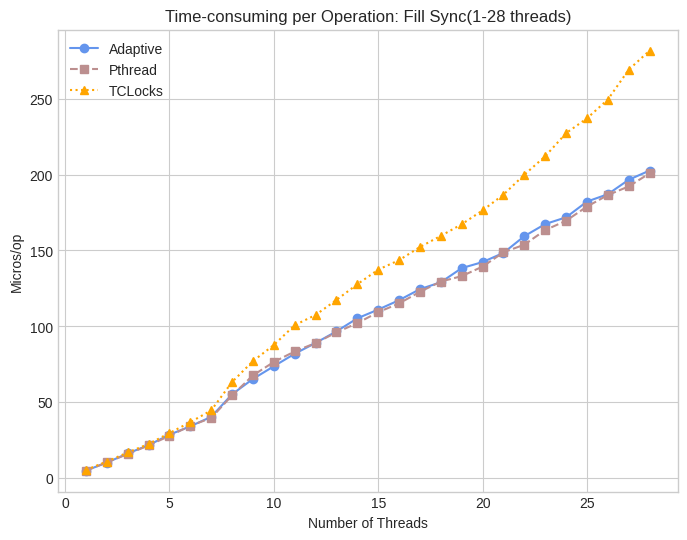

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_fillsync_x, adaptive_fillsync_y, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_fillsync_x, stock_fillsync_y, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_fillsync_x, komb_fillsync_y, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Fill Sync(1-28 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

# --- 设置轴的范围 (可选) ---
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 7) # 可能需要调整y轴范围以适应新的数据

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 在数据点旁添加文本注释 (可选，可以为每个系列分别添加或选择不添加) ---
# 为系列1添加注释
# for i, txt in enumerate(y1):
#     ax.annotate(txt, (x1[i], y1[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 为系列2添加注释
# for i, txt in enumerate(y2):
#     ax.annotate(txt, (x2[i], y2[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red') # 调整xytext避免重叠

# --- 添加注释 (可选) ---
# ax.annotate('交叉点', xy=(2.5, 3), xytext=(3, 4), # 示例注释
#             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
#             fontsize=12)

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('fillsync.png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()

In [1]:
import os
import re

def extract_data_from_file(filepath):
    """
    从单个文件中提取 readrandom 的 micros/op 值。
    """
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if "readmissing" in line and "micros/op" in line:
                    # 使用正则表达式提取数字
                    # readrandom   :       1.693 micros/op; (17722602)  (17722602 of 1000000 found)
                    match = re.search(r"readmissing\s*:\s*([\d.]+)\s*micros/op", line)
                    if match:
                        return float(match.group(1))
    except FileNotFoundError:
        print(f"警告: 文件 {filepath} 未找到。")
    except Exception as e:
        print(f"读取或解析文件 {filepath} 时出错: {e}")
    return None

def process_results(base_dir="leveldb"):
    """
    处理指定基础目录下的所有结果文件。
    """
    all_lock_data = {}

    if not os.path.isdir(base_dir):
        print(f"错误: 目录 '{base_dir}' 不存在。请确保脚本与 '{base_dir}' 目录在同一级别。")
        return

    for lock_type_dir in sorted(os.listdir(base_dir)):
        lock_type_path = os.path.join(base_dir, lock_type_dir)
        if os.path.isdir(lock_type_path):
            # 存储 (线程数, y值) 对，以便后续排序
            current_lock_values_with_threads = []
            for filename in sorted(os.listdir(lock_type_path)):
                if filename.startswith("readmissing."):
                    try:
                        # 从文件名 "readrandom.X" 中提取线程数 X
                        threads_str = filename.split('.')[-1]
                        threads = int(threads_str)
                        
                        filepath = os.path.join(lock_type_path, filename)
                        y_value = extract_data_from_file(filepath)
                        
                        if y_value is not None:
                            current_lock_values_with_threads.append((threads, y_value))
                    except ValueError:
                        print(f"警告: 无法从文件名 {filename} 解析线程数。")
                    except Exception as e:
                        print(f"处理文件 {filename} 时发生意外错误: {e}")
            
            if current_lock_values_with_threads:
                # 按线程数排序
                current_lock_values_with_threads.sort(key=lambda item: item[0])
                
                # 提取排序后的 y 值
                sorted_y_values = [item[1] for item in current_lock_values_with_threads]
                thread_counts = [item[0] for item in current_lock_values_with_threads] # 同时保存线程数用于打印

                all_lock_data[lock_type_dir] = {
                    "threads": thread_counts,
                    "y_values": sorted_y_values
                }

    # 打印结果
    print("# Python 代码硬编码数组:")
    for lock_type, data in all_lock_data.items():
        print(f"\n# {lock_type}")
        lock_type = lock_type.split('-')[0]  # 只取锁类型的第一个部分
        print(f"{lock_type}_readmissing_x = {data['threads']}")
        print(f"{lock_type}_readmissing_y = {data['y_values']}")
        # 如果只需要y值列表：
        # print(f"{lock_type}_data = {data['y_values']}")

if __name__ == "__main__":
    # 假设脚本与 'leveldb' 目录在同一级
    # 如果 'leveldb' 目录在其他位置，请修改这里的路径
    # 例如：process_results("path/to/your/leveldb")
    process_results('/home/haoling/TCLocks/doc/results/leveldb')

# Python 代码硬编码数组:

# adaptive-28
adaptive_readmissing_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_readmissing_y = [2.061, 2.523, 2.674, 3.525, 4.732, 5.233, 5.675, 7.332, 8.822, 9.719, 10.167, 10.561, 10.667, 11.096, 11.381, 11.412, 11.64, 12.083, 12.333, 12.818, 13.315, 14.004, 14.834, 15.397, 16.155, 16.465, 17.76, 21.953]

# komb-28
komb_readmissing_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_readmissing_y = [2.067, 2.614, 3.045, 3.637, 4.016, 4.587, 5.255, 6.824, 8.228, 9.257, 9.885, 10.342, 10.929, 11.544, 11.708, 11.836, 12.191, 12.569, 12.815, 12.891, 13.259, 14.31, 14.861, 15.562, 16.806, 17.484, 19.551, 22.48]

# stock-28
stock_readmissing_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_readmissing_y = [1.869, 2.272, 2.75, 3.188, 3.786, 4.231, 5.008, 7.041, 9.12, 11.617, 1

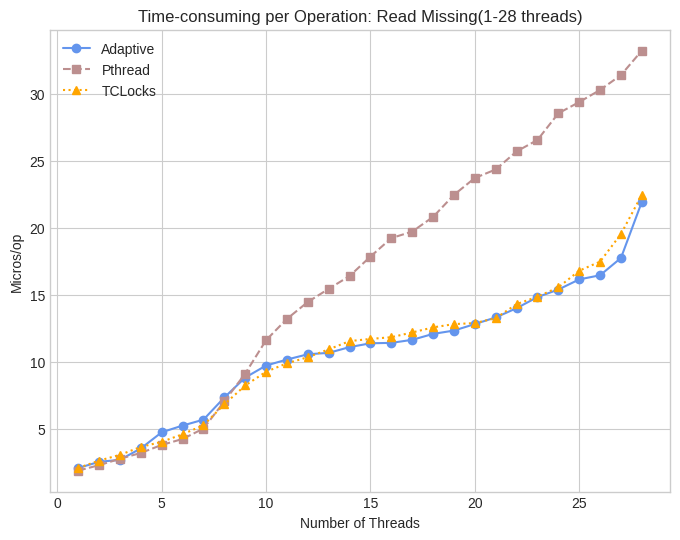

In [7]:
# Python 代码硬编码数组:

# adaptive-28
adaptive_readmissing_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
adaptive_readmissing_y = [2.061, 2.523, 2.674, 3.525, 4.732, 5.233, 5.675, 7.332, 8.822, 9.719, 10.167, 10.561, 10.667, 11.096, 11.381, 11.412, 11.64, 12.083, 12.333, 12.818, 13.315, 14.004, 14.834, 15.397, 16.155, 16.465, 17.76, 21.953]

# komb-28
komb_readmissing_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
komb_readmissing_y = [2.067, 2.614, 3.045, 3.637, 4.016, 4.587, 5.255, 6.824, 8.228, 9.257, 9.885, 10.342, 10.929, 11.544, 11.708, 11.836, 12.191, 12.569, 12.815, 12.891, 13.259, 14.31, 14.861, 15.562, 16.806, 17.484, 19.551, 22.48]

# stock-28
stock_readmissing_x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
stock_readmissing_y = [1.869, 2.272, 2.75, 3.188, 3.786, 4.231, 5.008, 7.041, 9.12, 11.617, 13.208, 14.472, 15.453, 16.409, 17.864, 19.242, 19.729, 20.826, 22.474, 23.735, 24.369, 25.72, 26.576, 28.567, 29.407, 30.314, 31.424, 33.254]

import matplotlib.pyplot as plt
import numpy as np

# --- 创建图像和轴对象 ---
# 内容全英文
fig, ax = plt.subplots(figsize=(8, 6))  # 可选：调整图像大小

# --- 绘制折线图 ---
# 绘制第一条折线
ax.plot(adaptive_readmissing_x, adaptive_readmissing_y, marker='o', linestyle='-', color='cornflowerblue', label='Adaptive') # marker='o' 表示圆形标记, linestyle='-' 表示实线

# 绘制第二条折线 (新的折线)
# 指定不同的颜色 (例如 'red') 和标签 (例如 '数据系列 2')
ax.plot(stock_readmissing_x, stock_readmissing_y, marker='s', linestyle='--', color='rosybrown',  label='Pthread') # marker='s' 表示方形标记, linestyle='--' 表示虚线

ax.plot(komb_readmissing_x, komb_readmissing_y, marker='^', linestyle=':', color='orange', label='TCLocks') # marker='^' 表示三角形标记, linestyle=':' 表示点线

# --- 添加标题和轴标签 ---
# 标题 读并发吞吐量
ax.set_title('Time-consuming per Operation: Read Missing(1-28 threads)')  # 修改标题
ax.set_xlabel('Number of Threads')  # 修改X轴标签
ax.set_ylabel('Micros/op')  # 修改Y轴标签

# --- 设置轴的范围 (可选) ---
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 7) # 可能需要调整y轴范围以适应新的数据

# --- 添加图例 ---
# ax.legend() 会自动收集所有指定了 label 的 plot 命令，并显示它们
ax.legend() # 可以调整图例字体大小

# # --- 添加网格线 (可选) ---
ax.grid(True) # 可以调整网格线样式和透明度

# --- 在数据点旁添加文本注释 (可选，可以为每个系列分别添加或选择不添加) ---
# 为系列1添加注释
# for i, txt in enumerate(y1):
#     ax.annotate(txt, (x1[i], y1[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 为系列2添加注释
# for i, txt in enumerate(y2):
#     ax.annotate(txt, (x2[i], y2[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red') # 调整xytext避免重叠

# --- 添加注释 (可选) ---
# ax.annotate('交叉点', xy=(2.5, 3), xytext=(3, 4), # 示例注释
#             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
#             fontsize=12)

# --- 设置刻度标签的大小 ---
plt.style.use('seaborn-v0_8-whitegrid')


# --- 保存图像 (可选) ---
plt.savefig('readmissing.png', dpi=300, bbox_inches='tight')  # bbox_inches='tight' 确保标签不被裁剪

# --- 显示图像 ---
plt.show()